# 📰 News Sentiment Dashboard — End-to-End Walkthrough

One runnable notebook that holds the **entire project**: scrape five news RSS
feeds → score each headline's sentiment with **VADER** → tag a topic → visualise
which topics and sources lean positive or negative.

This notebook *is* the project. Every piece of logic from the standalone modules
(`scrape.py`, `sentiment.py`, `topics.py`, `pipeline.py`) is **inlined** here and
runs top-to-bottom on **live data** — nothing is imported from the other files.

- **Live dashboard:** https://news-sentiment-dashboard-live.vercel.app
- **Repo:** https://github.com/george-gideon-S/news-sentiment-dashboard-live

---

### The flow

```
 RSS feeds  ─▶  scrape & clean  ─▶  VADER sentiment  ─▶  keyword topic  ─▶  DataFrame  ─▶  charts
(5 sources)     feedparser          compound score        tagging           pandas        matplotlib
```

### Tech stack & why

| Layer | Tool | Why this one |
|-------|------|--------------|
| Fetch RSS | **feedparser** | Eats malformed XML, weird encodings & a dozen date formats so we don't have to |
| Sentiment | **VADER** | Lexicon + rules, tuned for short punchy text — perfect for headlines, zero training |
| Wrangling | **pandas** | The obvious tool for anything tabular |
| Notebook charts | **matplotlib** | Renders inline *and* on GitHub (static images) |
| Local app | **Streamlit + Plotly** | Fastest way to stand up an interactive dashboard |
| Hosted | **static HTML + Plotly.js on Vercel** | A public URL anyone can open |


## Project structure

The repo keeps concerns in separate files; this notebook folds them all together.

```
feeds.py        the five feeds (single source of truth)
scrape.py       fetch + clean every feed (defensive: a dead feed is data, not a crash)
sentiment.py    VADER compound score + positive / neutral / negative label
topics.py       keyword-based topic tagging
pipeline.py     scrape → sentiment → topics → data/headlines.csv
app.py          Streamlit dashboard (local, interactive)
index.html      static dashboard for Vercel (Plotly.js, reads data.json)
core.py         lean scrape+score+tag engine for the serverless build
```

> **Setup:** this notebook needs `feedparser vaderSentiment pandas matplotlib`.
> Install once with: `pip install feedparser vaderSentiment pandas matplotlib`


## 0 · Imports

The whole stack is light — three third-party libraries plus the standard library.

In [1]:
%matplotlib inline
import calendar, html, re, socket, time
from datetime import datetime, timezone

import feedparser
import pandas as pd
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (8, 4.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
pd.set_option("display.max_colwidth", 90)

SENT_COLORS = {"positive": "#2ca02c", "neutral": "#9aa0a6", "negative": "#d62728"}
print("Imports OK · feedparser", feedparser.__version__, "· pandas", pd.__version__)

Imports OK · feedparser 6.0.12 · pandas 2.3.3


## 1 · The feeds

Everything is driven off this one list. Want another paper? Add a line — the rest
of the pipeline doesn't care how many feeds there are.

In [2]:
FEEDS = [
    {"name": "BBC",            "url": "http://feeds.bbci.co.uk/news/rss.xml"},
    {"name": "Times of India", "url": "https://timesofindia.indiatimes.com/rssfeedstopstories.cms"},
    {"name": "Al Jazeera",     "url": "https://www.aljazeera.com/xml/rss/all.xml"},
    {"name": "The Hindu",      "url": "https://www.thehindu.com/news/feeder/default.rss"},
    {"name": "NPR",            "url": "https://feeds.npr.org/1001/rss.xml"},
]
pd.DataFrame(FEEDS)

,name,url
0,BBC,http://feeds.bbci.co.uk/news/rss.xml
1,Times of India,https://timesofindia.indiatimes.com/rssfeedstopstories.cms
2,Al Jazeera,https://www.aljazeera.com/xml/rss/all.xml
3,The Hindu,https://www.thehindu.com/news/feeder/default.rss
4,NPR,https://feeds.npr.org/1001/rss.xml


## 2 · Scraping the feeds (defensively)

`feedparser` does the heavy lifting. Everything else here is **defence** — one
dead or slow feed must never take the whole run down:

- A **global socket timeout** so a hung feed can't block forever.
- A browser-ish **User-Agent** (some feeds 403 a bare client).
- A small **retry with backoff** — *The Hindu* reliably drops its first
  connection (`RemoteDisconnected`) and only answers on the second try.
- Failures are returned as **data** (an `ok=False` report), never raised.

In [3]:
socket.setdefaulttimeout(25)
USER_AGENT = ("Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 "
              "(KHTML, like Gecko) Chrome/124.0.0.0 Safari/537.36")
MAX_TRIES, RETRY_BACKOFF = 3, 1.5

_TAG_RE = re.compile(r"<[^>]+>")
_WS_RE = re.compile(r"\s+")

def clean_text(value):
    # Strip HTML tags, unescape entities, collapse whitespace.
    if not value:
        return ""
    return _WS_RE.sub(" ", html.unescape(_TAG_RE.sub(" ", value))).strip()

def published_dt(entry):
    # feedparser hands back a UTC struct_time; not every entry has one.
    tm = entry.get("published_parsed") or entry.get("updated_parsed")
    if not tm:
        return None
    return datetime.fromtimestamp(calendar.timegm(tm), tz=timezone.utc)

def fetch_feed(name, url):
    # Fetch one feed with retries. Never raises -- a dead feed reports ok=False.
    report = {"name": name, "ok": False, "count": 0, "http_status": None,
              "tries": 0, "error": None}
    for attempt in range(1, MAX_TRIES + 1):
        report["tries"] = attempt
        parsed = None
        try:
            parsed = feedparser.parse(url, agent=USER_AGENT)
        except Exception as exc:                       # RemoteDisconnected, timeout...
            report["error"] = f"{type(exc).__name__}: {exc}"
        if parsed is not None:
            report["http_status"] = parsed.get("status")
            if parsed.entries:
                now = datetime.now(timezone.utc)
                rows = []
                for e in parsed.entries:
                    title = clean_text(e.get("title"))
                    if not title:
                        continue
                    rows.append({
                        "source": name, "title": title,
                        "summary": clean_text(e.get("summary") or e.get("description")),
                        "link": e.get("link", ""),
                        "published": published_dt(e), "fetched_at": now,
                    })
                report.update(ok=True, count=len(rows), error=None)
                return rows, report
            report["error"] = str(parsed.get("bozo_exception", "no entries"))
        if attempt < MAX_TRIES:
            time.sleep(RETRY_BACKOFF * attempt)        # transient? give it a beat
    return [], report

def fetch_all(feeds=FEEDS):
    # Fetch every feed, concat, dedupe. Returns (DataFrame, per-feed reports).
    rows, reports = [], []
    for f in feeds:
        r, rep = fetch_feed(f["name"], f["url"])
        rows.extend(r); reports.append(rep)
    df = pd.DataFrame(rows)
    if not df.empty:
        df = df.drop_duplicates(subset=["source", "title"]).reset_index(drop=True)
        df["published"] = pd.to_datetime(df["published"], utc=True, errors="coerce")
    return df, reports

print("scrape functions defined")

scrape functions defined


Run it live. The report shows each feed's health — watch *The Hindu* take
`tries=2` thanks to the retry.

In [4]:
raw, reports = fetch_all()
pd.DataFrame(reports)[["name", "ok", "http_status", "tries", "count", "error"]]

,name,ok,http_status,tries,count,error
0,BBC,True,302,1,34,None
1,Times of India,True,200,1,44,None
2,Al Jazeera,True,200,1,25,None
3,The Hindu,True,200,1,60,None
4,NPR,True,200,1,10,None


In [5]:
print(f"Pulled {len(raw)} headlines from {raw['source'].nunique()} feeds")
raw[["source", "title", "published"]].head(8)

Pulled 173 headlines from 5 feeds


,source,title,published
0,BBC,Celebrated British artist David Hockney dies aged 88,2026-06-12 14:03:35+00:00
1,BBC,Ministers want 60% of children walking or cycling to school by 2035,2026-06-12 14:24:08+00:00
2,BBC,"Grooming survivors left with criminal records still being failed, BBC told",2026-06-12 05:03:32+00:00
3,BBC,Donaldson denies meeting sex abuse accuser to 'nip in the bud' allegations,2026-06-12 14:14:13+00:00
4,BBC,London council takes possession of property linked to Sierra Leone's First Lady,2026-06-12 13:05:29+00:00
5,BBC,Taylor Swift makes tearful 21-minute speech as she joins Songwriters Hall of Fame,2026-06-12 11:12:11+00:00
6,BBC,"My friends always want to split the bill equally, how do I say no?",2026-06-11 23:00:29+00:00
7,BBC,Israeli tech firm accused of targeting First Minister John Swinney in election,2026-06-12 13:18:09+00:00


## 3 · Sentiment with VADER

**Why VADER and not a trained model?** Headlines are short, punchy and almost
social-media-ish in tone — exactly what VADER was tuned for. It's lexicon + rules,
needs zero training data, and returns a single `compound` score in `[-1, 1]` that's
trivial to bucket at ±0.05.

In [6]:
analyzer = SentimentIntensityAnalyzer()
POS_CUTOFF, NEG_CUTOFF = 0.05, -0.05

def label_for(c):
    return "positive" if c >= POS_CUTOFF else "negative" if c <= NEG_CUTOFF else "neutral"

def score_title(title):
    s = analyzer.polarity_scores(title or "")
    return pd.Series({"sent_compound": round(s["compound"], 4),
                      "sent_label": label_for(s["compound"])})

df = raw.copy()
df[["sent_compound", "sent_label"]] = df["title"].apply(score_title)
df[["source", "sent_compound", "sent_label", "title"]].head(8)

,source,sent_compound,sent_label,title
0,BBC,0.5719,positive,Celebrated British artist David Hockney dies aged 88
1,BBC,0.0772,positive,Ministers want 60% of children walking or cycling to school by 2035
2,BBC,-0.7717,negative,"Grooming survivors left with criminal records still being failed, BBC told"
3,BBC,-0.7906,negative,Donaldson denies meeting sex abuse accuser to 'nip in the bud' allegations
4,BBC,0.0000,neutral,London council takes possession of property linked to Sierra Leone's First Lady
5,BBC,0.5719,positive,Taylor Swift makes tearful 21-minute speech as she joins Songwriters Hall of Fame
6,BBC,0.5267,positive,"My friends always want to split the bill equally, how do I say no?"
7,BBC,-0.2960,negative,Israeli tech firm accused of targeting First Minister John Swinney in election


**Know the limitation.** VADER is a lexicon — it reads words, not meaning.
Watch it call an obituary *positive* because the word "celebrated" is strongly
positive and it has no idea "dies" is the actual story. Read the **aggregates**,
not any single score.

In [7]:
for t in ["Taylor Swift joins the Songwriters Hall of Fame",
          "Celebrated British artist David Hockney dies aged 88",
          "Three killed as cross-border attacks continue"]:
    print(f"{analyzer.polarity_scores(t)['compound']:+.3f}   {t}")

+0.572   Taylor Swift joins the Songwriters Hall of Fame
+0.572   Celebrated British artist David Hockney dies aged 88
-0.813   Three killed as cross-border attacks continue


## 4 · Topic tagging (by keyword)

This is the corner we cut **on purpose**. Real topic modelling (zero-shot,
BERTopic) is overkill for v1 and a pain to keep running. A keyword map gets ~80%
of the way, is fully explainable ("why Sports? because it said *World Cup*"), and
anyone can tune it by editing a list. When the keywords start embarrassing you —
that's the cue to reach for a model.

In [8]:
TOPIC_KEYWORDS = {
    "Politics": ["election", "parliament", "minister", "president", "senate",
                 "congress", "government", "vote", "policy", "diplomat", "modi",
                 "trump", "biden", "putin", "campaign", "lawmaker", "summit"],
    "Conflict & War": ["war", "ukraine", "gaza", "israel", "hamas", "strike",
                       "military", "troops", "attack", "missile", "ceasefire",
                       "conflict", "killed", "rebel", "airstrike", "hostage"],
    "Business": ["economy", "market", "stocks", "inflation", "trade", "bank",
                 "rupee", "dollar", "gdp", "company", "ipo", "profit", "tariff",
                 "oil price", "investor", "shares", "revenue"],
    "Technology": ["artificial intelligence", "tech", "software", "chip",
                   "google", "apple", "microsoft", "openai", "iphone",
                   "cyber", "robot", "semiconductor", "app store"],
    "Sports": ["cricket", "football", "soccer", "world cup", "olympic", "match",
               "tournament", "ipl", "fifa", "tennis", "nba", "champion",
               "league", "wicket", "goal"],
    "Health": ["health", "covid", "virus", "vaccine", "hospital", "disease",
               "outbreak", "mental health", "cancer", "medical", "flu"],
    "Science & Environment": ["climate", "space", "nasa", "weather", "flood",
                              "earthquake", "wildfire", "environment", "research",
                              "study", "emissions", "heatwave", "cyclone", "monsoon"],
    "Entertainment": ["film", "movie", "music", "actor", "celebrity", "bollywood",
                      "hollywood", "box office", "award", "concert", "festival"],
    "Crime & Justice": ["court", "police", "arrest", "murder", "trial", "verdict",
                        "fraud", "crime", "jail", "lawsuit", "probe"],
}
DEFAULT_TOPIC = "General"
_COMPILED = {topic: [re.compile(r"\b" + re.escape(k) + r"\b") for k in kws]
             for topic, kws in TOPIC_KEYWORDS.items()}

def classify(text):
    t = (text or "").lower()
    best, best_hits = DEFAULT_TOPIC, 0
    for topic, pats in _COMPILED.items():
        hits = sum(1 for p in pats if p.search(t))
        if hits > best_hits:
            best, best_hits = topic, hits
    return best

df["topic"] = df["title"].apply(classify)
df["topic"].value_counts()

topic
General                  112
Sports                    19
Politics                  11
Conflict & War            10
Crime & Justice            8
Entertainment              4
Health                     3
Science & Environment      2
Technology                 2
Business                   2
Name: count, dtype: int64

## 5 · The combined dataset

That's the whole pipeline — `scrape → sentiment → topics` — landed in one tidy
DataFrame. This is exactly what `pipeline.py` writes to `data/headlines.csv`.

In [9]:
print("Sentiment mix:", df["sent_label"].value_counts().to_dict())
print("Shape:", df.shape)
df[["source", "topic", "sent_label", "sent_compound", "title"]].head(10)

Sentiment mix: {'negative': 74, 'neutral': 59, 'positive': 40}
Shape: (173, 9)


,source,topic,sent_label,sent_compound,title
0,BBC,General,positive,0.5719,Celebrated British artist David Hockney dies aged 88
1,BBC,General,positive,0.0772,Ministers want 60% of children walking or cycling to school by 2035
2,BBC,General,negative,-0.7717,"Grooming survivors left with criminal records still being failed, BBC told"
3,BBC,General,negative,-0.7906,Donaldson denies meeting sex abuse accuser to 'nip in the bud' allegations
4,BBC,General,neutral,0.0000,London council takes possession of property linked to Sierra Leone's First Lady
5,BBC,General,positive,0.5719,Taylor Swift makes tearful 21-minute speech as she joins Songwriters Hall of Fame
6,BBC,General,positive,0.5267,"My friends always want to split the bill equally, how do I say no?"
7,BBC,Politics,negative,-0.2960,Israeli tech firm accused of targeting First Minister John Swinney in election
8,BBC,Sports,negative,-0.2960,'No-one knows it's on' - NBA Finals feed US World Cup apathy
9,BBC,Sports,negative,-0.2960,From near death to tournament hero - Jimenez's tears for Mexico


## 6 · Visualise it

The whole point of the dashboard, in three charts.

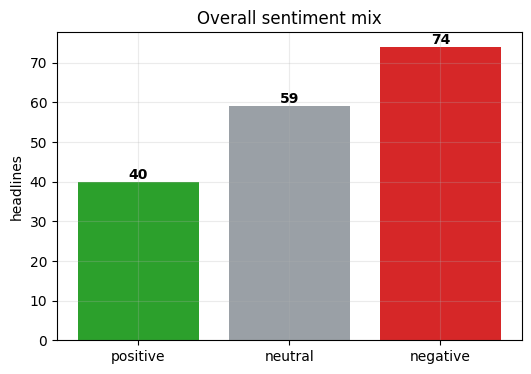

In [10]:
mix = df["sent_label"].value_counts().reindex(["positive", "neutral", "negative"]).fillna(0)
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(mix.index, mix.values, color=[SENT_COLORS[k] for k in mix.index])
for i, v in enumerate(mix.values):
    ax.text(i, v, int(v), ha="center", va="bottom", fontweight="bold")
ax.set_title("Overall sentiment mix"); ax.set_ylabel("headlines")
plt.show()

**The money chart** — which topics lean which way. Sorted, zero line marked,
coloured red→green by average compound.

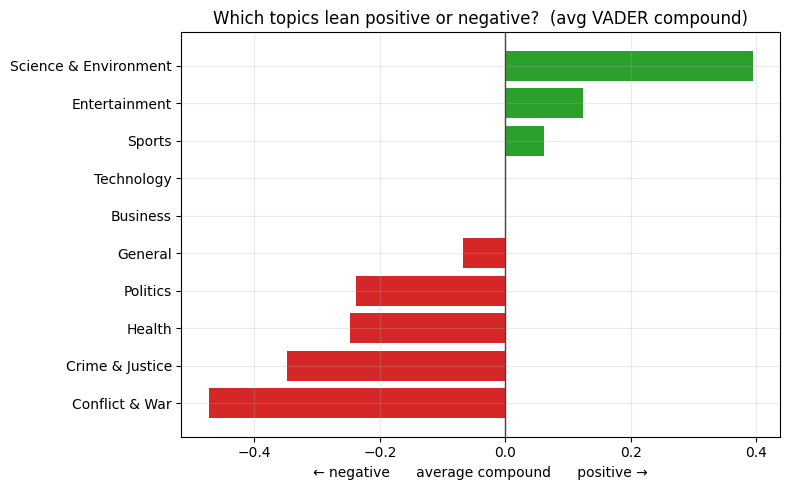

In [11]:
ts = df.groupby("topic")["sent_compound"].mean().sort_values()
colors = ["#d62728" if v < -0.05 else "#2ca02c" if v > 0.05 else "#9aa0a6" for v in ts.values]
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(ts.index, ts.values, color=colors)
ax.axvline(0, color="#444", lw=1)
ax.set_title("Which topics lean positive or negative?  (avg VADER compound)")
ax.set_xlabel("← negative      average compound      positive →")
plt.tight_layout(); plt.show()

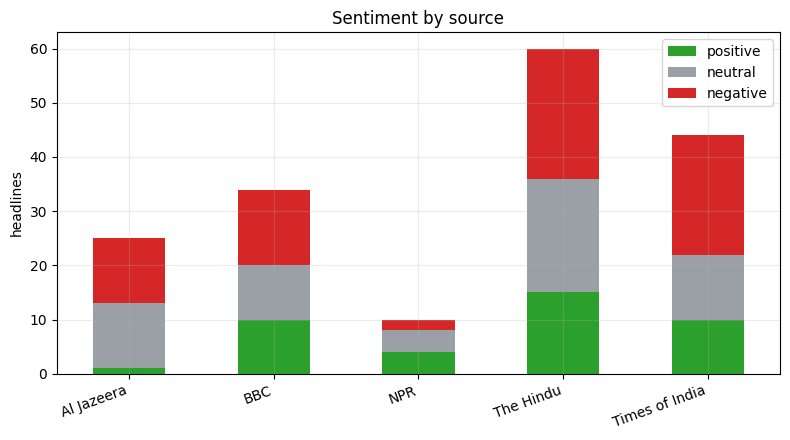

In [12]:
ct = (df.groupby(["source", "sent_label"]).size().unstack(fill_value=0)
        .reindex(columns=["positive", "neutral", "negative"], fill_value=0))
ax = ct.plot(kind="bar", stacked=True, figsize=(8, 4.5),
             color=[SENT_COLORS[c] for c in ct.columns])
ax.set_title("Sentiment by source"); ax.set_ylabel("headlines"); ax.set_xlabel("")
plt.xticks(rotation=20, ha="right"); plt.legend(title="")
plt.tight_layout(); plt.show()

The extremes — the headlines driving the numbers at each end.

In [13]:
print("MOST NEGATIVE")
for _, r in df.nsmallest(5, "sent_compound").iterrows():
    print(f"  {r.sent_compound:+.2f}  [{r.source}] {r.title[:72]}")
print("\nMOST POSITIVE")
for _, r in df.nlargest(5, "sent_compound").iterrows():
    print(f"  {r.sent_compound:+.2f}  [{r.source}] {r.title[:72]}")

MOST NEGATIVE
  -0.94  [Al Jazeera] Riots, violence, hate: Anti-immigrant unrest spells danger in Belfast
  -0.83  [Al Jazeera] Family mourn Indian sailor killed in US strike on oil tanker
  -0.83  [The Hindu] 6-year-old’s murder in Bengaluru: Three police officers suspended for de
  -0.82  [The Hindu] Two killed in road accident
  -0.80  [Al Jazeera] A year after Air India crash killed 260: Do we know what happened?

MOST POSITIVE
  +0.80  [The Hindu] Water level in dams goes up steadily to revive hopes of better ‘kar’ pad
  +0.77  [Times of India] 'From an opponent to a friend': Kohli pens heartfelt farewell message fo
  +0.68  [The Hindu] Govt. non-committal on LDF’s free UG promise; FYUGP review on the cards
  +0.68  [BBC] 'I've never been this good' – revolutionary immune reset puts lupus in r
  +0.64  [Times of India] Kick Streamer reveals real reason why he is distancing himself from UFC 


## 7 · Persist (what `pipeline.py` does)

The producer writes a cache; the dashboards only ever read it. That split is what
keeps the UI fast and stops it hammering the feeds on every interaction.

In [14]:
import pathlib
pathlib.Path("data").mkdir(exist_ok=True)
df.to_csv("data/headlines.csv", index=False)
print(f"Wrote data/headlines.csv  ({len(df)} rows, {df.shape[1]} columns)")

Wrote data/headlines.csv  (173 rows, 9 columns)


## 8 · From notebook to product

The same pipeline powers two front-ends.

**Local — Streamlit (`app.py`)** — an interactive dashboard with filters and a live
Refresh button. The key trick is caching, because Streamlit reruns the whole script
on every interaction:

```python
@st.cache_data(ttl=900)
def load_data():
    return pipeline.load_cache()        # read the CSV, not re-scrape

# charts with Plotly, filters in the sidebar, a "Refresh feeds" button that
# re-runs the pipeline and clears the cache.
```

Run it: `streamlit run app.py` → http://localhost:8501

**Hosted — static site on Vercel (`index.html` + `data.json`)** — Streamlit is a
stateful server and can't run on Vercel's serverless model, so the hosted version
is a static page that renders a committed `data.json` snapshot with Plotly.js. A
lean `core.py` (feedparser + VADER only, no pandas) regenerates that snapshot.

→ **Live:** https://news-sentiment-dashboard-live.vercel.app


## 9 · Recap — decisions & cut corners

| Decision | Call | Trade-off |
|----------|------|-----------|
| Sentiment | **VADER** (lexicon) | Instant & explainable; mis-reads context like *"celebrated … dies"* |
| Topics | **keyword map** | Transparent & tunable; ~half of headlines land in *General* |
| Scope of scoring | **headline title only** | That's "headline sentiment"; summaries muddy the signal |
| Resilience | **retry + global timeout** | One feed can't hang or kill the run |

**Where to go next:** swap VADER for a finetuned headline model behind the same
`score_title()` signature, and the keyword tagger for a zero-shot classifier behind
`classify()` — both are drop-ins because the seams are kept clean.

---
*Repo: https://github.com/george-gideon-S/news-sentiment-dashboard-live · Live:
https://news-sentiment-dashboard-live.vercel.app*
